In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('Housing.csv')

print("--- Dataset Preview ---")
display(df.head())

print("\n--- Dataset Info & Columns ---")
print(df.info())

--- Dataset Preview ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



--- Dataset Info & Columns ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [ ]:
# Automatically detects text columns and convert them to 0s and 1s
text_columns = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=text_columns, drop_first=True)

print("--- Preprocessed Dataset Preview ---")
display(df_encoded.head())

--- Preprocessed Dataset Preview ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [ ]:
# Defines Features (X) and Target Variable (y)
X = df_encoded.drop(columns=['price']) # Drops target variable (Note: lowercase 'price' or uppercase 'Price')
if 'Price' in df_encoded.columns:
    X = df_encoded.drop(columns=['Price'])
    y = df_encoded['Price']
else:
    y = df_encoded['price']

# Split data into train-test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (436, 13)
Testing features shape: (109, 13)


In [ ]:
# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Makes predictions
y_pred = model.predict(X_test)
print("Model trained successfully using your Kaggle dataset!")

Model trained successfully using your Kaggle dataset!


In [ ]:
# Evaluates model metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 970043.40
Mean Squared Error (MSE): 1754318687330.66
Root Mean Squared Error (RMSE): 1324506.96
R² Score: 0.6529


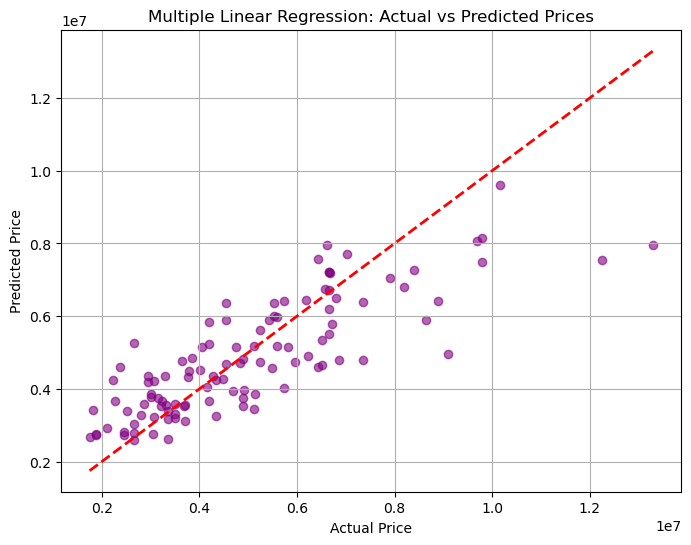

--- Model Coefficients ---
                        Feature   Coefficient
                           area  2.359688e+02
                       bedrooms  7.677870e+04
                      bathrooms  1.094445e+06
                        stories  4.074766e+05
                        parking  2.248419e+05
                   mainroad_yes  3.679199e+05
                  guestroom_yes  2.316100e+05
                   basement_yes  3.902512e+05
            hotwaterheating_yes  6.846499e+05
            airconditioning_yes  7.914267e+05
                   prefarea_yes  6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
   furnishingstatus_unfurnished -4.136451e+05


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')

# Perfect predictions line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Multiple Linear Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

# Showing the weights/coefficients assigned to each feature
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("--- Model Coefficients ---")
print(coefficients.to_string(index=False))